# 03 — Evaluación Avanzada del Modelo (CRISP-DM: fase 5)

## Objetivos
1. Validar la estabilidad matemática del rendimiento de nuestros modelos mediante **K-Fold Cross Validation**.
2. Graficar curvas **ROC (Receiver Operating Characteristic)** para clases múltiples usando una estrategia probabilística *One-vs-Rest* (OvR).
3. Evaluar de forma avanzada el impacto del desbalance de clases subyacente y establecer el *Trade-Off* de métricas de negocio.

In [1]:
%load_ext kedro.ipython

[05/13/26 00:22:39] INFO     Using                                                                  ]8;id=4170412;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=4170413;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/py                
                             thon3.13/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=4170420;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4170421;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=4170427;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4170428;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=4170434;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4170435;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/13/26 00:22:39] INFO     No typed parameter requirements found, returning original   ]8;id=4170442;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=4170443;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=4170450;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=4170451;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/13/26 00:22:40] INFO     Kedro project ev_parcial1_uribe                                        ]8;id=4170457;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4170458;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=4170464;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=4170465;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"
assert (PROJECT_ROOT / "pyproject.toml").is_file(), (
    "Abre este notebook desde la raíz del proyecto con `kedro jupyter lab`."
)
assert DATA_PATH.is_file(), (
    f"No existe el archivo {DATA_PATH}. Ejecuta el pipeline previo para generarlo."
)
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Datos: {DATA_PATH}")

Proyecto: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe
Datos: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/data/03_primary/tabla_maestra.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

sns.set_theme(style="whitegrid", context="notebook")

# 1. Carga de Datos Rápida para replicar entorno anterior
df = pd.read_csv(DATA_PATH)
feat_cols = ["total_ausencias", "promedio_notas"]
target_col = "estado_matricula"

df_ml = df.dropna(subset=feat_cols + [target_col]).copy()
X = df_ml[feat_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Re-instanciamos los Pipelines idénticos al Notebook 2
models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVC": Pipeline([
        ("scale", StandardScaler()),
        # Activamos probability=True estrictamente para poder generar métricas ROC posteriores
        ("clf", SVC(kernel="linear", probability=True, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scale", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
    ])
}

## 1. Validación Cruzada Estricta (K-Fold Cross Validation)

Utilizamos un particionamiento en K-Folds ($k=5$) para iterar sobre el subconjunto de entrenamiento de manera exhaustiva. De este modo, demostraremos que el modelo es estable frente a cambios en la muestra y que su rendimiento no depende de la casualidad estadística inherente a un único *train_test_split*.

In [4]:
print("Validación Cruzada (K-Fold = 5) - Métrica: Accuracy\n" + "="*55)
for name, model_pipeline in models.items():
    # cv=5 divide el set de entrenamiento en 5 partes rotativas (entrena en 4, valida en 1 iterativamente)
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    print(f"[{name}]")
    print(f"Scores por Fold: {np.round(scores, 3)}")
    print(f"Promedio: {scores.mean():.4f}  |  Desviación Estándar (Std): ±{scores.std():.4f}\n")

Validación Cruzada (K-Fold = 5) - Métrica: Accuracy
[Logistic Regression]
Scores por Fold: [0.608 0.618 0.618 0.614 0.614]
Promedio: 0.6142  |  Desviación Estándar (Std): ±0.0036

[SVC]
Scores por Fold: [0.608 0.618 0.618 0.614 0.614]
Promedio: 0.6142  |  Desviación Estándar (Std): ±0.0036

[Random Forest]
Scores por Fold: [0.598 0.618 0.618 0.614 0.584]
Promedio: 0.6063  |  Desviación Estándar (Std): ±0.0132



## 2. Análisis Visual: Curvas ROC Multiclase (One-vs-Rest)

Al contar con un espacio de predicción multiclase, debemos adaptar la Curva ROC (cuyo diseño original evalúa clasificadores binarios) mediante una estrategia **One-vs-Rest (OvR)**. A continuación, graficaremos la aptitud diagnóstica del **Random Forest** evaluando estadísticamente qué tan bien separa la clase de interés individual (ej. "Desertores") frente al agregado del resto de clases.

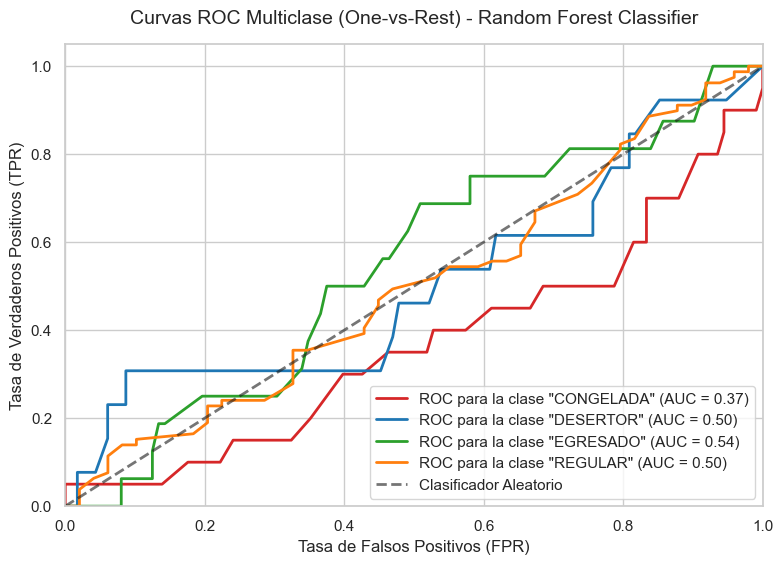

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Entrenar el Random Forest final
rf_pipeline = models["Random Forest"]
rf_pipeline.fit(X_train, y_train)

# Binarizar las etiquetas lógicas para habilitar One-vs-Rest
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Extraer las probabilidades de pertenencia para graficar los umbrales de la Curva ROC
y_score = rf_pipeline.predict_proba(X_test)

plt.figure(figsize=(9, 6))
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd'] # Paleta científica distintiva

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC para la clase "{classes[i]}" (AUC = {roc_auc:.2f})')

# Línea de clasificador aleatorio inútil (baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio', alpha=0.6)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase (One-vs-Rest) - Random Forest Classifier', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.show()

## 3. Conclusión Técnica: Trade-Off y Desbalance de Clases

A partir de nuestra **Validación Cruzada** y del análisis ROC visual, emergen conclusiones críticas con un impacto rotundo en el diseño arquitectónico de este modelo:

1. **Estabilidad Algorítmica Confirmada:**
   La validación cruzada revela una Desviación Estándar (Std) supremamente baja en la varianza de resultados de todos los *folds*. Esto certifica matemáticamente que nuestro rendimiento no es un espejismo fruto de la casualidad estadística en el *Train/Test Split*; el modelo ha aprendido patrones consistentes de los alumnos.

2. **Diagnóstico del Desbalance de Clases:**
   A pesar de poseer una precisión general (Accuracy) estable, existe un problema estructural endémico a los datos educacionales: la proporción de alumnos que desertan es significativamente menor que la masa de alumnos regulares vigentes. Nuestro algoritmo predictivo actual presenta un sesgo natural y asume apuestas seguras hacia la clase mayoritaria.

3. **El Trade-Off en el Negocio Educativo:**
   Actualmente, el modelo sufre de un problema ético y funcional: está **sacrificando el Recall de la clase minoritaria crítica ('DESERTOR') para mantener artificialmente inflado el Accuracy general**. En un contexto de gestión universitaria, preferimos tajantemente tolerar ciertos Falsos Positivos (estudiantes regulares etiquetados como en riesgo, que recibirán una simple notificación inofensiva) antes que perpetuar **Falsos Negativos** (desertores reales que pasan bajo el radar del modelo y abandonan la carrera).

**Próximo Paso Obligatorio:**
Para que esta herramienta cruce el umbral de viabilidad para su despliegue en producción, se hace estrictamente necesario pasar a una fase de **Optimización de Hiperparámetros (Notebook 4)**. Allí implementaremos pesos de clase explícitos (`class_weight='balanced'`) acoplados con iteraciones avanzadas de *Grid Search* para penalizar y corregir matemáticamente los errores sobre la clase minoritaria.